# Setup

In [1]:
from data.cleaning import read_csv
from core import Config
import pandas as pd

config = Config()
TARGET = config.TARGET

static_df: pd.DataFrame = read_csv(
    config.selected_dir / "selected_static.csv",
    config.selected_dir / "selected_static_dtypes.csv",
    [0]
)

historic_df: pd.DataFrame = read_csv(
    config.selected_dir / "selected_historic.csv",
    config.selected_dir / "selected_historic_dtypes.csv",
    [0]
)


# Filter and convert historic dataframe
# Detect columns with only boolean-like strings and convert dtype to boolean
def is_bool_string_col(series):
    bool_strings = [{'true', 'false'}, {'True', 'False'}, {'yes', 'no'}, {'Yes', 'No'}, {'1', '0'}]
    values = set(series.dropna().unique())
    return any(values <= s for s in bool_strings)


def transform_bool_strings(dataframe: pd.DataFrame) -> pd.DataFrame:
    df = dataframe.copy()
    for col in df.select_dtypes(include=['object', 'string']):
        if is_bool_string_col(df[col]):
            df[col] = df[col].replace(
                {'true': True, 'True': True, 'yes': True, 'Yes': True, '1': True,
                 'false': False, 'False': False, 'no': False, 'No': False, '0': False}).astype('boolean')
            df[col] = df[col].astype('boolean')
    return df


# remove columns with only one unique (non‑NaN) value
def remove_columns_with_only_one_unique_value(dataframe: pd.DataFrame) -> pd.DataFrame:
    df = dataframe.copy()
    nunique = df.nunique(dropna=True)
    cols_to_drop = nunique[nunique == 1].index
    return df.drop(columns=cols_to_drop)


historic_df = transform_bool_strings(historic_df)
historic_df = remove_columns_with_only_one_unique_value(historic_df)

# Join static and historic dataframe to have GICS Sector Codes in the dataframe
all_df = historic_df.merge(
    static_df,
    on='Instrument',
    how='left'
)

all_df = remove_columns_with_only_one_unique_value(all_df)

## Manuall Filter

In [2]:
# Manually remove redundant data
all_df.drop(
    [
        'TR.HeadquartersCountry',
        'TR.BusinessSector',
        'TR.TRBCActivity',
        'TR.TRBCIndustry',
        'TR.NAICSSector',
        'TR.NACEClassification',
    ], axis=1, inplace=True)

# Create labeled DataFrame with row filtered emtpy Scope3.1
labeled_df: pd.DataFrame = all_df.dropna(subset=[TARGET])

# Analyse Scope 3.1 and Winzorise

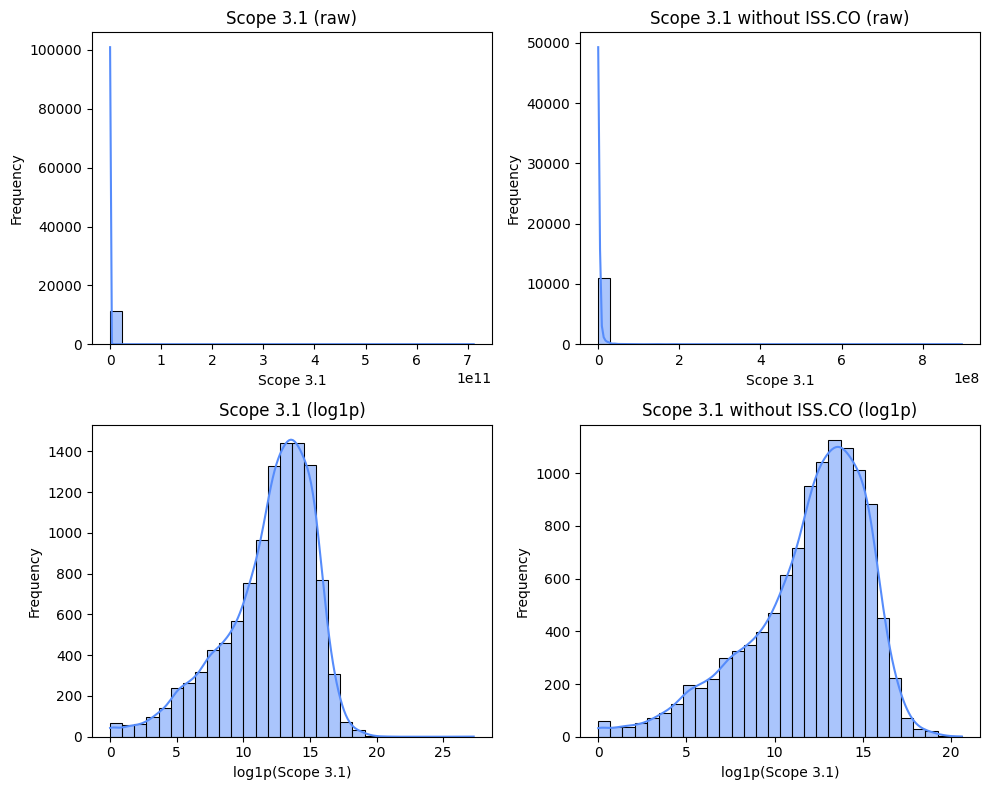

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Analyze Scope 3.1 data
scope31_values: pd.Series = labeled_df[TARGET].dropna()

# TODO maybe remove ISS.CO because its values are so high. When winsorized on log scale, scope 3.1 is 0.01 higher and 4 more rows remain
no_iss_values: pd.Series = (
    labeled_df[~labeled_df['Instrument'].str.contains('ISS.CO')][TARGET].dropna()
)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
ax_raw, ax_no_iss_raw, ax_log, ax_no_iss_log = axes.ravel()

# Raw
sns.histplot(scope31_values, kde=True, bins=30, ax=ax_raw)
ax_raw.set_title("Scope 3.1 (raw)")
ax_raw.set_xlabel("Scope 3.1")
ax_raw.set_ylabel("Frequency")

# No ISS.CO raw
sns.histplot(no_iss_values, kde=True, bins=30, ax=ax_no_iss_raw)
ax_no_iss_raw.set_title("Scope 3.1 without ISS.CO (raw)")
ax_no_iss_raw.set_xlabel("Scope 3.1")
ax_no_iss_raw.set_ylabel("Frequency")

# Result is heavily skewed to the right
# log1p target value for normal distribution
scope31_values_log = np.log1p(scope31_values)
no_iss_values_log = np.log1p(no_iss_values)

# log1p
sns.histplot(scope31_values_log, kde=True, bins=30, ax=ax_log)
ax_log.set_title("Scope 3.1 (log1p)")
ax_log.set_xlabel("log1p(Scope 3.1)")
ax_log.set_ylabel("Frequency")

# No ISS.CO log1p
sns.histplot(no_iss_values_log, kde=True, bins=30, ax=ax_no_iss_log)
ax_no_iss_log.set_title("Scope 3.1 without ISS.CO (log1p)")
ax_no_iss_log.set_xlabel("log1p(Scope 3.1)")
ax_no_iss_log.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Winsorize

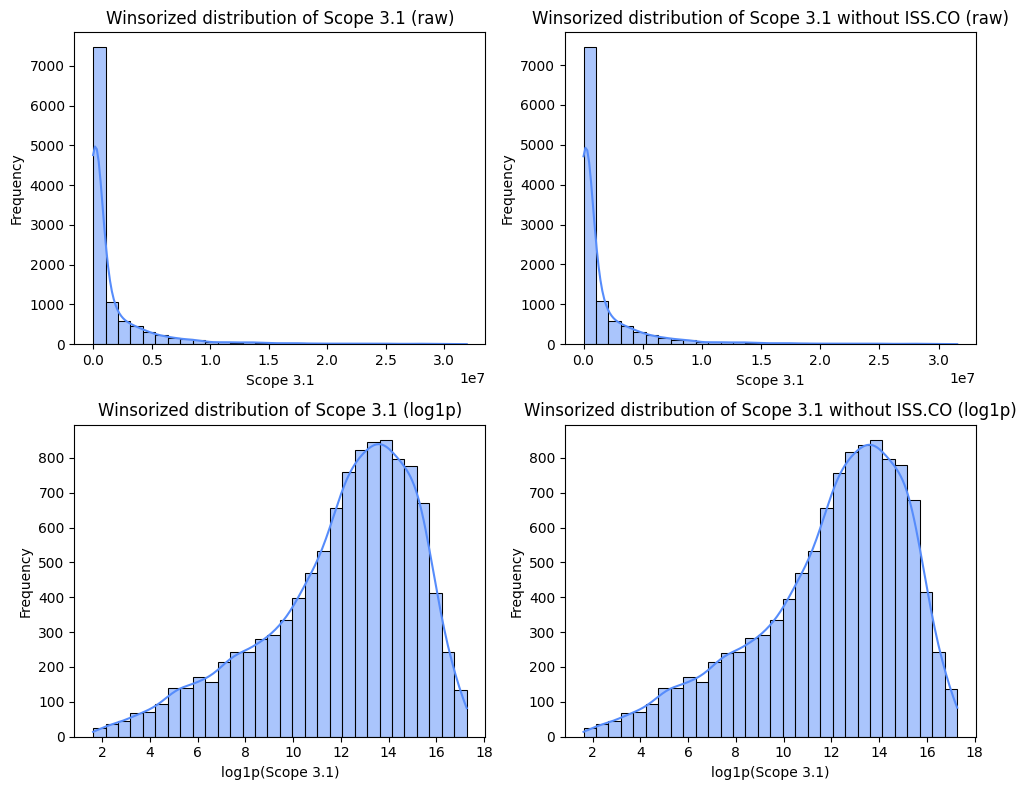

In [4]:
# Winsorize first and 99th quantile of column Scope 3.1
def winsorize_series(s, q_low=0.01, q_high=0.99, bins=100) -> pd.Series:
    # s: 1D Series
    q = pd.qcut(s, bins, labels=False)
    return s[(q > 0) & (q < bins - 1)]

winsorized: pd.Series = winsorize_series(scope31_values)
winsorized_no_iss: pd.Series = winsorize_series(no_iss_values)
winsorized_log: pd.Series = winsorize_series(scope31_values_log)
winsorized_no_iss_log: pd.Series = winsorize_series(no_iss_values_log)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
ax_raw, ax_no_iss_raw, ax_log, ax_no_iss_log = axes.ravel()

# Raw
sns.histplot(winsorized, kde=True, bins=30, ax=ax_raw)
ax_raw.set_title("Winsorized distribution of Scope 3.1 (raw)")
ax_raw.set_xlabel("Scope 3.1")
ax_raw.set_ylabel("Frequency")

# No ISS.CO raw
sns.histplot(winsorized_no_iss, kde=True, bins=30, ax=ax_no_iss_raw)
ax_no_iss_raw.set_title("Winsorized distribution of Scope 3.1 without ISS.CO (raw)")
ax_no_iss_raw.set_xlabel("Scope 3.1")
ax_no_iss_raw.set_ylabel("Frequency")

# log1p
sns.histplot(winsorized_log, kde=True, bins=30, ax=ax_log)
ax_log.set_title("Winsorized distribution of Scope 3.1 (log1p)")
ax_log.set_xlabel("log1p(Scope 3.1)")
ax_log.set_ylabel("Frequency")

# No ISS.CO log1p
sns.histplot(winsorized_no_iss_log, kde=True, bins=30, ax=ax_no_iss_log)
ax_no_iss_log.set_title("Winsorized distribution of Scope 3.1 without ISS.CO (log1p)")
ax_no_iss_log.set_xlabel("log1p(Scope 3.1)")
ax_no_iss_log.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [5]:
# use Winsorize series to reduce labeled dataset
mask = labeled_df.index.isin(winsorized.index)
winsorized_labeled_df: pd.DataFrame = labeled_df.loc[mask]

# Missingness

In [6]:
# calculate missingness untouched labeled dataframe